Import libraries

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

import collections

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

import pathlib

from sklearn.metrics import classification_report, confusion_matrix




Autotune Data

In [ ]:
autotune = tf.data.AUTOTUNE
batch_size = 32
img_size = (150, 150)
class_names = ['normal', 'pneumonia', 'tuberculosis']
buffer_size = 10000

In [11]:
data_root = pathlib.Path( r"/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive")

In [12]:
train_dir = data_root/'train'
val_dir = data_root/'val'
test_dir = data_root/'test'

In [15]:
train_ds =tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size = img_size,
    color_mode = 'grayscale',
    batch_size = batch_size,
    shuffle = True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size = img_size,
    color_mode = 'grayscale',
    batch_size = batch_size,
    shuffle =False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size = img_size,
    color_mode = 'grayscale',
    batch_size = batch_size,
    shuffle = False
)

print('Inferred Class Names:', class_names)
num_classes = len(class_names)

Found 20450 files belonging to 3 classes.
Found 2534 files belonging to 3 classes.
Found 2569 files belonging to 3 classes.
Inferred Class Names: ['normal', 'pneumonia', 'tuberculosis']


In [16]:
train_ds = train_ds.cache().shuffle(buffer_size).prefetch(buffer_size = autotune)
val_ds = val_ds.cache().prefetch(buffer_size = autotune)
test_ds = test_ds.cache().prefetch(buffer_size = autotune)


Calculate class weights to handle class imbalance

In [17]:


class_counts = collections.Counter()

for _, labels in train_ds:
    class_counts.update(labels.numpy().tolist())
print('Class Counts:', class_counts)

normal_iamage_count = class_counts[0]
pneumonia_image_count = class_counts[1]
tuberculosis_image_count = class_counts[2]
total_image_count = sum(class_counts.values())

weight_for_normal = total_image_count / (3 * normal_iamage_count)
weight_for_pneumonia = total_image_count / (3 * pneumonia_image_count)
weight_for_tuberculosis = total_image_count / (3 * tuberculosis_image_count)
class_weight = {
    0: weight_for_normal, 
    1: weight_for_pneumonia, 
    2: weight_for_tuberculosis}

print('Class Weights:' , class_weight)

    

Class Counts: Counter({2: 8513, 0: 7263, 1: 4674})
Class Weights: {0: 0.9385469732433797, 1: 1.4584224789616318, 2: 0.8007361290575199}


2025-11-16 03:58:59.542333: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Visualize Data

2025-11-16 03:59:23.772388: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


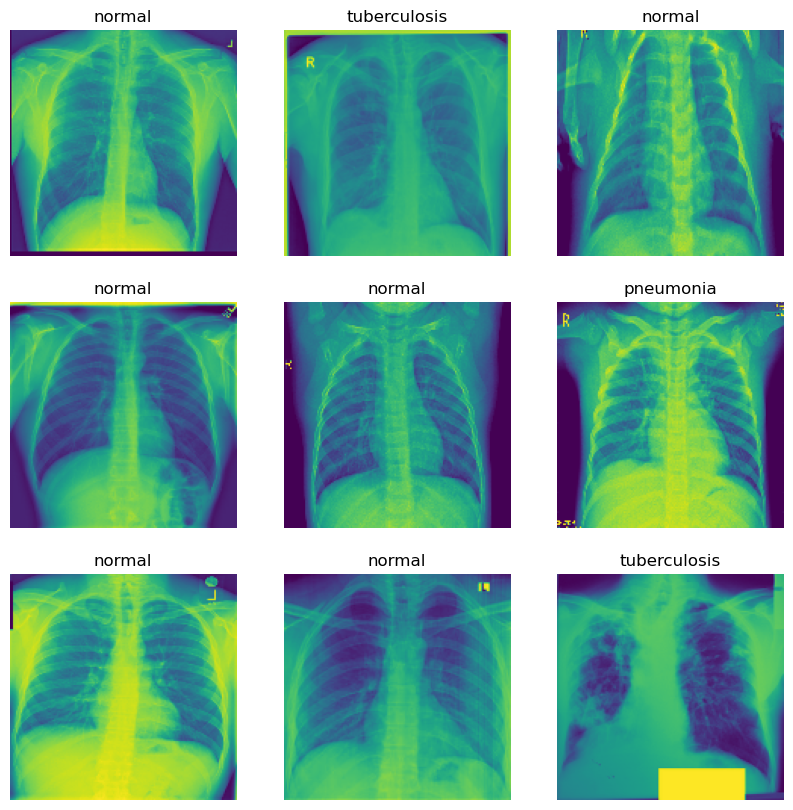

In [19]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(np.squeeze(images[i].numpy().astype('uint8')))
        plt.title(class_names[labels[i]])
        plt.axis('off')

Build CNN

In [20]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

inputs = tf.keras.Input(shape = img_size + (1,))
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(1./255)(x)

x = tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(128, activation = 'relu')(x)

outputs = tf.keras.layers.Dense(num_classes, activation = 'softmax')(x)

model = tf.keras.Model(inputs = inputs, outputs = outputs)


In [21]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,571 (428.01 KB)

 Trainable params: 109,571 (428.01 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [22]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20,
    class_weight = class_weight
)

Epoch 1/20


2025-11-16 03:59:52.552588: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


640/640 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.5408 - loss: 0.8701 - val_accuracy: 0.5939 - val_loss: 0.8018
Epoch 2/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.5985 - loss: 0.7636 - val_accuracy: 0.6069 - val_loss: 0.7816
Epoch 3/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4934 - loss: 1.0420 - val_accuracy: 0.5533 - val_loss: 1.0367
Epoch 4/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4340 - loss: 1.5828 - val_accuracy: 0.4692 - val_loss: 2.4554
Epoch 5/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4557 - loss: 4.2192 - val_accuracy: 0.4700 - val_loss: 14.1812
Epoch 6/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4572 - loss: 8.4061 - val_accuracy: 0.4475 - val_loss: 5.6488
Epoch 7/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4555 - loss: 17.7146 - val_accuracy: 0.4661 - val_loss: 16.0476
Epoch 8/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4492 - loss: 27.3376 - val_acc

Evaluate

In [23]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4893 - loss: 366.7317
Test Accuracy: 0.4893


In [69]:
model.save('xray classification_model1.keras')

Test Accuracy: 0.4893
original image shape 150,150
original learning rate

Build Second Model to test improvements in model

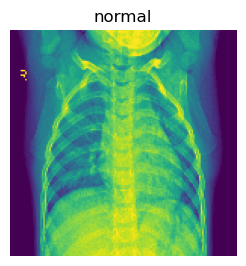

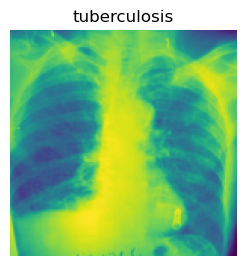

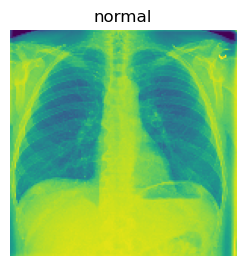

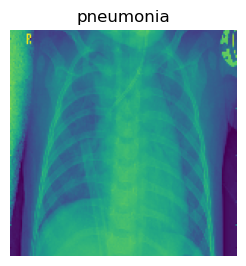

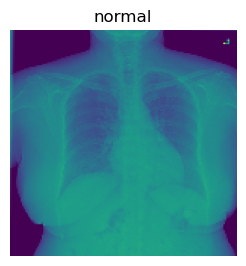

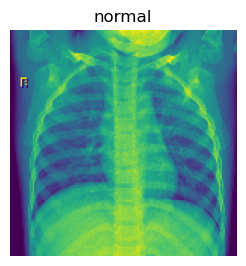

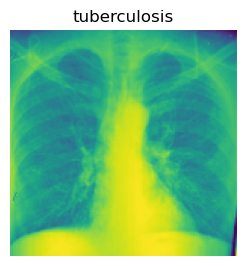

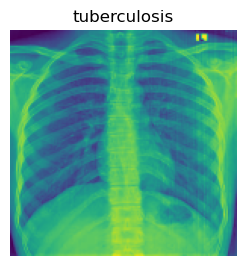

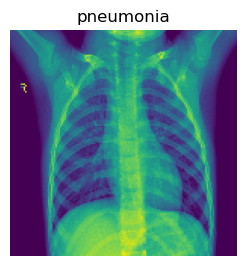

2025-11-16 04:20:30.306925: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [35]:

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.figure(figsize=(10, 10))         
        plt.subplot(3, 3 , i + 1)
        plt.imshow(np.squeeze(images[i].numpy().astype('uint8')))
        plt.title(class_names[labels[i]])
        plt.axis('off')
        plt.show()

Reload data with new size

In [ ]:
img_size2 = (224, 224)
batch_size2 = 32
num_classes2 = len(class_names)

train_ds2 = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size = img_size2,
    color_mode = 'grayscale',
    batch_size = batch_size2,
    shuffle = True
)

val_ds2 = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size = img_size2,
    color_mode = 'grayscale',
    batch_size = batch_size2,
    shuffle = False
)

test_ds2 = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size = img_size2,
    color_mode = 'grayscale',
    batch_size = batch_size2,
    shuffle = False
)
print('Inferred Class Names:', class_names)

Found 20450 files belonging to 3 classes.
Found 2534 files belonging to 3 classes.
Found 2569 files belonging to 3 classes.
Inferred Class Names: ['normal', 'pneumonia', 'tuberculosis']


In [57]:
Autotune = tf.data.AUTOTUNE
train_ds2 = train_ds2.cache().shuffle(buffer_size).prefetch(buffer_size = Autotune)
val_ds2 = val_ds2.cache().prefetch(buffer_size = Autotune)
test_ds2 = test_ds2.cache().prefetch(buffer_size = Autotune)

data_augmentation2 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])


Pretrained backbone

In [63]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top = False,
    input_shape = img_size2 + (3,),
    weights = 'imagenet'
)
# Freeze the base model
base_model.trainable = False
# Reload data with new size
inputs2 = tf.keras.Input(shape = img_size2 + (1,))
x2 = data_augmentation2(inputs2)
# Rescale grayscale to 3 channels
x2 = tf.keras.layers.Rescaling(1./255)(x2)
# Convert grayscale to RGB by repeating channels
x2 = tf.keras.layers.Concatenate()([x2, x2, x2])

x2 =  base_model(x2, training =False)
x2 = tf.keras.layers.GlobalAveragePooling2D()(x2)
x2 = tf.keras.layers.Dropout(0.4)(x2)
outputs2 = tf.keras.layers.Dense(num_classes2, activation = 'softmax')(x2)

Build Model

In [ ]:
model2 = tf.keras.Model(inputs2, outputs2)
model2.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-3),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

# Continue with training model2
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

Tune training setup

In [70]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = 5,
        restore_best_weights = True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 2,
        min_lr = 1e-6
    )
]

history2 = model2.fit(
    train_ds2,
    validation_data = val_ds2,
    epochs = 30,
    class_weight = class_weight,
    callbacks = callbacks
)

Epoch 1/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.3410 - loss: 1.1205 - val_accuracy: 0.3552 - val_loss: 1.1228 - learning_rate: 0.0010
Epoch 2/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.3279 - loss: 1.1173 - val_accuracy: 0.2249 - val_loss: 1.1249 - learning_rate: 0.0010
Epoch 3/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 49s 76ms/step - accuracy: 0.3314 - loss: 1.1156 - val_accuracy: 0.4199 - val_loss: 1.0961 - learning_rate: 0.0010
Epoch 4/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.3313 - loss: 1.1152 - val_accuracy: 0.2249 - val_loss: 1.1684 - learning_rate: 0.0010
Epoch 5/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 49s 76ms/step - accuracy: 0.3224 - loss: 1.1152 - val_accuracy: 0.3552 - val_loss: 1.0841 - learning_rate: 0.0010
Epoch 6/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 49s 76ms/step - accuracy: 0.3298 - loss: 1.1147 - val_accuracy: 0.4199 - val_loss: 1.0715 - learning_rate: 0.0010
Epoch 7/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.3338 - l